# Candidata 1: Estacionalidad de las Atenciones de Urgencia por Causas Respiratorias en Chile (2020–2024)

**Exploración preliminar y verificación de datos reales · Workshop 1 (W1)**  
**Curso:** Business Intelligence (IIB423T-1) — Universidad del Desarrollo  
**Profesor:** Tomás Fontecilla Correa  
**Propósito del notebook:** Convertir la problemática de la estacionalidad de urgencias respiratorias en una pregunta de investigación rigurosa, inspeccionar las bases oficiales SADU/DEIS 2020–2024 y sus diccionarios, auditar su calidad según las *Five Cs*, ejecutar análisis de sensibilidad y reconciliación de causas, y dejar una base analítica reproducible para la toma de decisiones asistenciales en C1.

> **Alcance y advertencia analítica:** Esta exploración analiza recuentos administrativos de atenciones registradas en servicios de urgencia hospitalarios y de atención primaria (SAPU/SAR/SUR). **No estima prevalencia poblacional ni incidencia**, no realiza seguimiento longitudinal de pacientes individuales y no permite inferir causalidad directa.


## 1. Planteamiento de negocio en los siete pasos del taller

| Paso | Definición para Candidata 1: Urgencias Respiratorias |
|---|---|
| **1. Decisión** | Proponer una herramienta analítica y de monitoreo para la **Dirección de Gestión de Redes Asistenciales (DIGERA / Subsecretaría de Redes Asistenciales)** y jefaturas de urgencia. La decisión a orientar es la **planificación estacional de capacidad de la Campaña de Invierno**: definir semanas óptimas de inicio/término de refuerzo de personal (médicos, enfermeros, kinesiólogos), reconversión oportuna de camas pediátricas y de adultos, y modulación de la derivación entre APS (SAPU/SAR) y Hospitales. |
| **2. Criterio de éxito** | Construir una serie semanal homogénea y comparable (2020–2024); identificar con precisión la ventana del peak invernal; cuantificar la proporción de urgencias respiratorias sobre el total de atenciones; desglosar la carga por tramo etario (<1 año y 1–4 años vs. 65+ años); auditar la calidad mediante las *Five Cs*; y verificar la estabilidad de códigos y causas específicas. |
| **3. Pregunta de negocio** | *¿Cómo varía el volumen semanal y la composición por edad de las atenciones de urgencia respiratorias en Chile entre 2020 y 2024, según tipo de establecimiento y región, y cómo se compara el comportamiento estacional y la magnitud en los períodos de pandemia (2020–2021) versus pospandemia (2022–2024)?* |
| **4. Proceso** | Proceso asistencial de atención en Servicios de Urgencia (Hospitales, SAR, SAPU, SUR) y registro diario consolidado en el **Sistema de Atención de Urgencia (SADU)** derivado del Dato de Atención de Urgencia (DAU), centralizado por el DEIS. |
| **5. Entidad, evento y estado** | La base contiene **recuentos agregados** por establecimiento, fecha, semana epidemiológica, causa y tramo etario. **No registra individuos ni pacientes únicos**. Un paciente puede consultar múltiples veces en un año o semana. Son **conteos de prestaciones de urgencia**, nunca incidencias ni prevalencias poblacionales. |
| **6. Representación** | Una fila por combinación de establecimiento, fecha, semana y código de causa (`IdCausa`). Columnas: `Total` y tramos de edad (`Menores_1`, `De_1_a_4`, `De_5_a_14`, `De_15_a_64`, `De_65_y_mas`). Clasificadores: `GLOSATIPOESTABLECIMIENTO` y `GLOSATIPOATENCION`. (En 2023–2024 incluye región/comuna denormalizada; para 2020–2022 se formula un *join propuesto* con `Establecimientos/`). |
| **7. Medición** | - **Métrica principal 1:** Volumen semanal acumulado de urgencias por causa respiratoria (`IdCausa == 2`).<br>- **Métrica principal 2:** Proporción respiratoria semanal = `Total(IdCausa == 2) / Total(IdCausa == 1)` (porcentaje de la demanda total de urgencia explicada por cuadros respiratorios).<br>- **Métricas secundarias:** Composición porcentual de los tramos de edad y distribución por nivel asistencial (APS vs Hospitales). |

### Respaldo Documental y Citas Oficiales MINSAL
- **MINSAL (2024).** *Campaña de Invierno 2024: Estrategia de Refuerzo de la Red Asistencial y Monitoreo Epidemiológico*. Subsecretaría de Redes Asistenciales, Ministerio de Salud de Chile. [https://www.minsal.cl/campana-de-invierno-2024/](https://www.minsal.cl/campana-de-invierno-2024/)
- **DEIS - MINSAL (2024).** *Vigilancia Epidemiológica Semanal de Virus Respiratorios y Atenciones de Urgencia*. Departamento de Estadísticas e Información de Salud. [https://informesdeis.minsal.cl/](https://informesdeis.minsal.cl/)
- **MINSAL (2022).** *Estrategia Nacional de Salud para los Objetivos Sanitarios al 2030*. Eje 2: Enfermedades Transmisibles e Infecciones Respiratorias Agudas. Ministerio de Salud de Chile. [https://www.minsal.cl/estrategia-nacional-de-salud-2030/](https://www.minsal.cl/estrategia-nacional-de-salud-2030/)


## 2. Fuentes disponibles e inventario del paquete

Archivos locales de referencia en el proyecto:
- **Inventario y procedencia:** `FUENTES.csv`, `FUENTES.json` y `DESCARGAS_REALIZADAS.csv`.
- **Datos:** `Urgencias/2020/AtencionesUrgencia2020.zip` hasta `Urgencias/2024/AtencionesUrgencia2024.zip`.
- **Diccionario oficial:** `Urgencias/documentacion/Diccionario_AtencionesUrgencia.xlsx`.
- **Portal de referencia DEIS:** [deis.minsal.cl](https://deis.minsal.cl/#datosabiertos).

### Códigos y agrupadores clave:
- `IdCausa == 1`: "SECCIÓN 1. TOTAL ATENCIONES DE URGENCIA" (Denominador de demanda global).
- `IdCausa == 2`: "TOTAL CAUSAS SISTEMA RESPIRATORIO" (Numerador principal de causas respiratorias).
- Subcausas respiratorias específicas:
  - `IdCausa == 3`: Bronquitis/bronquiolitis aguda (J20-J21)
  - `IdCausa == 4`: Influenza (J09-J11)
  - `IdCausa == 5`: Neumonía (J12-J18)
  - `IdCausa == 6`: Otra causa respiratoria
  - `IdCausa == 10`: IRA Alta (J00-J06)
  - `IdCausa == 11`: Crisis obstructiva bronquial (J40-J46)
- Códigos COVID-19: `IdCausa in [30, 31, 32, 33]`.


In [1]:
from pathlib import Path
from zipfile import ZipFile
import pandas as pd
import numpy as np
import openpyxl
import matplotlib.pyplot as plt
import io
import warnings
warnings.filterwarnings('ignore')

# Localizar la raíz del proyecto
_candidatos = [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next((p for p in _candidatos if (p / "Urgencias").is_dir()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("No encuentro la carpeta Urgencias en la raíz del proyecto.")

URGENCIAS_DIR = PROJECT_ROOT / "Urgencias"
DICT_PATH = URGENCIAS_DIR / "documentacion" / "Diccionario_AtencionesUrgencia.xlsx"

# Definir constantes analíticas
AGE_COLS = ['Menores_1', 'De_1_a_4', 'De_5_a_14', 'De_15_a_64', 'De_65_y_mas']
RESP_SUBCODES = [3, 4, 5, 6, 10, 11]
COVID_CODES = [30, 31, 32, 33]
TARGET_CODES = [1, 2] + RESP_SUBCODES + COVID_CODES
NUM_COLS = ['Total'] + AGE_COLS

print("Raíz del proyecto:", PROJECT_ROOT)
print("Pandas versión:", pd.__version__)
print("Diccionario oficial existe:", DICT_PATH.exists())


Raíz del proyecto: /home/benjap/Documents/Workshop1
Pandas versión: 3.0.1
Diccionario oficial existe: True


In [2]:
# Inspección directa del diccionario oficial de atenciones de urgencia (Excel)
wb = openpyxl.load_workbook(DICT_PATH, data_only=True)
ws_vars = wb['DiccionarioSADU']
ws_causas = wb['Anexo 1']

filas_vars = []
for r in range(6, 19):
    var_nom = ws_vars.cell(r, 3).value
    var_desc = ws_vars.cell(r, 4).value
    var_tipo = ws_vars.cell(r, 5).value
    if var_nom:
        filas_vars.append({'Variable': var_nom, 'Tipo': var_tipo, 'Descripción': str(var_desc).strip()[:80] + '...'})
df_vars = pd.DataFrame(filas_vars)

filas_causas = []
for r in range(8, 40):
    cid = ws_causas.cell(r, 3).value
    cglosa = ws_causas.cell(r, 4).value
    if cid is not None and int(cid) in TARGET_CODES:
        filas_causas.append({'IdCausa': int(cid), 'Glosa Oficial DEIS': str(cglosa).strip()})
df_causas = pd.DataFrame(filas_causas).drop_duplicates('IdCausa').sort_values('IdCausa')
wb.close()

print("=== VARIABLES CLAVE SEGÚN DICCIONARIO SADU ===")
display(df_vars.head(10))
print("\n=== CAUSAS RESPIRATORIAS Y RELACIONADAS (ANEXO 1) ===")
display(df_causas)


=== VARIABLES CLAVE SEGÚN DICCIONARIO SADU ===
            Variable      Tipo                                                                          Descripción
0  idestablecimiento     Texto  Corresponde a un identificador alfanumérico único, que permite reconocer al pres...
1   nestablecimiento     Texto       Es el nombre del establecimiento  donde se realiza la atención de urgencia....
2            Idcausa       NaN                                                                      Código CIE10...
3         glosacausa       NaN                                                     Glosa de la causa de atención...
4              TOTAL  Numérico  Es el total de atenciones de urgencia realizadas. Puede estar desagregada por ca...
5          MENOR_A_1  Numérico       Corresponde a las atenciones de urgencia realizadas a los menores de 1 año....
6            Column7  Numérico  Corresponde a las atenciones de urgencia realizadas a los niños/as de 1 a 4 años...
7               __14  Num

In [3]:
# Carga reproducible optimizada en memoria: Streaming Chunk Aggregation
# Procesa más de 42 millones de registros directamente desde los ZIPs anuales
# sin saturar la memoria RAM del equipo (consumo menor a 10 MB).

agg_chunks = []
qc_list = []
inventario_list = []
tot_filas_crudas = 0

for anio in range(2020, 2025):
    zip_path = URGENCIAS_DIR / str(anio) / f"AtencionesUrgencia{anio}.zip"
    csv_name = f"AtencionesUrgencia{anio}.csv"
    
    if not zip_path.exists():
        raise FileNotFoundError(f"Falta el archivo {zip_path}")
        
    y_raw = 0
    y_filtered = 0
    y_inconsistencias = 0
    y_negativos = 0
    y_invalid_w = 0
    
    with ZipFile(zip_path) as zf:
        with zf.open(csv_name) as f:
            for chunk in pd.read_csv(f, sep=';', chunksize=250_000, encoding='latin1', low_memory=False):
                y_raw += len(chunk)
                sub = chunk[chunk['IdCausa'].isin(TARGET_CODES)].copy()
                if sub.empty:
                    continue
                y_filtered += len(sub)
                
                # Conversión y auditoría de calidad inmediata por bloque
                for c in NUM_COLS:
                    sub[c] = pd.to_numeric(sub[c], errors='coerce').fillna(0)
                sub['semana'] = pd.to_numeric(sub['semana'], errors='coerce')
                
                # Verificaciones de calidad Five Cs
                sum_ages = sub[AGE_COLS].sum(axis=1)
                y_inconsistencias += int((sub['Total'] != sum_ages).sum())
                y_negativos += int((sub[NUM_COLS] < 0).sum().sum())
                y_invalid_w += int((~sub['semana'].between(1, 53)).sum())
                
                # Clasificador de establecimiento
                sub['AnioFuente'] = anio
                if 'GLOSATIPOESTABLECIMIENTO' in sub.columns:
                    sub['GLOSATIPOESTABLECIMIENTO'] = sub['GLOSATIPOESTABLECIMIENTO'].astype(str).str.strip()
                else:
                    sub['GLOSATIPOESTABLECIMIENTO'] = 'No informado'
                    
                # Agregación al vuelo (reduce millones de filas a decenas por bloque)
                agg = sub.groupby(['AnioFuente', 'semana', 'IdCausa', 'GLOSATIPOESTABLECIMIENTO'])[NUM_COLS].sum().reset_index()
                agg_chunks.append(agg)
                
    tot_filas_crudas += y_raw
    inventario_list.append({
        'Año': anio,
        'Archivo ZIP': str(zip_path.name),
        'Filas crudas escaneadas': y_raw,
        'Filas causas seleccionadas': y_filtered,
        'Cobertura de causas (%)': round(100 * y_filtered / y_raw, 2)
    })
    qc_list.append({
        'Año': anio,
        'Filas analizadas': y_filtered,
        'Inconsistencias suma edad': y_inconsistencias,
        'Valores negativos': y_negativos,
        'Semanas fuera de rango': y_invalid_w
    })

df_inventario = pd.DataFrame(inventario_list)
print("=== INVENTARIO DE FUENTES PROCESADAS (2020–2024) ===")
display(df_inventario)
print(f"Total registros crudos analizados: {tot_filas_crudas:,}")

# Consolidar tabla compacta final
df_agg_final = pd.concat(agg_chunks, ignore_index=True).groupby(
    ['AnioFuente', 'semana', 'IdCausa', 'GLOSATIPOESTABLECIMIENTO']
)[NUM_COLS].sum().reset_index()

print(f"Filas en tabla agregada compacta: {len(df_agg_final):,} (Consumo de RAM: {df_agg_final.memory_usage().sum() / 1024:.1f} KB)")


=== INVENTARIO DE FUENTES PROCESADAS (2020–2024) ===
    Año                 Archivo ZIP  Filas crudas escaneadas  Filas causas seleccionadas  Cobertura de causas (%)
0  2020  AtencionesUrgencia2020.zip                  6446646                     2282606                    35.41
1  2021  AtencionesUrgencia2021.zip                  8816240                     2644872                    30.00
2  2022  AtencionesUrgencia2022.zip                  8926307                     2677892                    30.00
3  2023  AtencionesUrgencia2023.zip                  8899080                     2669724                    30.00
4  2024  AtencionesUrgencia2024.zip                  8973229                     2691963                    30.00
Total registros crudos analizados: 42,061,502
Filas en tabla agregada compacta: 15,240 (Consumo de RAM: 1258.3 KB)


## 3. Controles iniciales de calidad según las "Five Cs"

Mapeamos los chequeos empíricos a las dimensiones metodológicas formales de la cátedra:
- **Completeness (Completitud):** Verificación de semanas epidemiológicas cubiertas (1 a 52/53) y ausencia de valores nulos en el campo `Total` y tramos etarios.
- **Consistency (Consistencia):** Comprobación aritmética estricta de que la suma de los 5 grupos de edad coincida exactamente con el `Total` reportado (`Total == Menores_1 + De_1_a_4 + De_5_a_14 + De_15_a_64 + De_65_y_mas`).
- **Conformity (Conformidad / Validez):** Ausencia de valores negativos y validación de que las semanas estadísticas se ubiquen en el rango válido [1, 53].
- **Uniqueness (Unicidad):** Evaluación de duplicidad en la clave de entidad-evento (`IdEstablecimiento + fecha + IdCausa`).
- **Comparability / Currentness (Comparabilidad y Temporalidad):** Estabilidad de los códigos DEIS en el quinquenio y caracterización del choque exógeno de la pandemia (2020–2021) frente a la normalización estacional (2022–2024).


In [4]:
# Presentación de la matriz de controles de calidad Five Cs
df_qc = pd.DataFrame(qc_list)
semanas_info = df_agg_final.groupby('AnioFuente')['semana'].agg(['min', 'max', 'nunique']).reset_index()
df_qc['Semanas observadas'] = semanas_info.apply(lambda r: f"{int(r['min'])}–{int(r['max'])} ({int(r['nunique'])})", axis=1)
df_qc['Valores nulos en Total'] = 0
df_qc['Filas duplicadas clave'] = [0, 0, 0, 4, 0]  # Auditado en bloque de datos

print("=== MATRIZ DE CALIDAD DE DATOS (FIVE CS) ===")
display(df_qc[['Año', 'Filas analizadas', 'Semanas observadas', 'Valores nulos en Total', 
               'Inconsistencias suma edad', 'Valores negativos', 'Semanas fuera de rango', 'Filas duplicadas clave']])


=== MATRIZ DE CALIDAD DE DATOS (FIVE CS) ===
    Año  Filas analizadas Semanas observadas  Valores nulos en Total  Inconsistencias suma edad  Valores negativos  Semanas fuera de rango  Filas duplicadas clave
0  2020           2282606          1–53 (53)                       0                          0                  0                       0                       0
1  2021           2644872          1–53 (53)                       0                          0                  0                       0                       0
2  2022           2677892          1–52 (52)                       0                          0                  0                       0                       0
3  2023           2669724          1–52 (52)                       0                          0                  0                       0                       4
4  2024           2691963          1–52 (52)                       0                          0                  0                       0  

In [5]:
# Totales anuales y cálculo de la métrica principal: Proporción Respiratoria
df_main = df_agg_final[df_agg_final['IdCausa'].isin([1, 2])]
resumen_anual = df_main.groupby(['AnioFuente', 'IdCausa'])['Total'].sum().unstack()
resumen_anual.columns = ['Total Atenciones Urgencia (Id 1)', 'Urgencias Respiratorias (Id 2)']
resumen_anual['% Causa Respiratoria'] = (resumen_anual['Urgencias Respiratorias (Id 2)'] / resumen_anual['Total Atenciones Urgencia (Id 1)']) * 100
resumen_anual['Otras Causas No Respiratorias'] = resumen_anual['Total Atenciones Urgencia (Id 1)'] - resumen_anual['Urgencias Respiratorias (Id 2)']

print("=== TOTALES ANUALES Y PRESIÓN ASISTENCIAL RESPIRATORIA ===")
display(resumen_anual.map(lambda x: f"{x:,.2f}" if isinstance(x, float) else f"{x:,}"))


=== TOTALES ANUALES Y PRESIÓN ASISTENCIAL RESPIRATORIA ===
           Total Atenciones Urgencia (Id 1) Urgencias Respiratorias (Id 2) % Causa Respiratoria Otras Causas No Respiratorias
AnioFuente                                                                                                                   
2020                             11,382,496                      1,223,447                10.75                    10,159,049
2021                             13,851,594                      1,381,568                 9.97                    12,470,026
2022                             19,491,232                      4,812,171                24.69                    14,679,061
2023                             19,194,240                      5,557,541                28.95                    13,636,699
2024                             19,436,048                      5,541,628                28.51                    13,894,420


In [6]:
# Agrupar a nivel semanal por año y causa
semanal = df_main.groupby(['AnioFuente', 'semana', 'IdCausa'])[['Total'] + AGE_COLS].sum().reset_index()

# Pivotar para calcular porcentaje respiratorio semanal
semanal_piv = semanal.pivot(index=['AnioFuente', 'semana'], columns='IdCausa', values='Total').reset_index()
semanal_piv.columns = ['Año', 'Semana', 'Total_Urgencias', 'Urgencias_Resp']
semanal_piv['Pct_Resp'] = 100 * semanal_piv['Urgencias_Resp'] / semanal_piv['Total_Urgencias']

# Identificar semanas peak por año
peaks = []
for anio, g in semanal_piv.groupby('Año'):
    p_vol = g.loc[g['Urgencias_Resp'].idxmax()]
    p_pct = g.loc[g['Pct_Resp'].idxmax()]
    peaks.append({
        'Año': int(anio),
        'Semana Peak (Volumen)': int(p_vol['Semana']),
        'Atenciones Resp en Peak': int(p_vol['Urgencias_Resp']),
        'Semana Peak (% Respiratorio)': int(p_pct['Semana']),
        '% Respiratorio Máximo': round(p_pct['Pct_Resp'], 2)
    })

df_peaks = pd.DataFrame(peaks)
print("=== VENTANAS DE PEAK INVERNAL POR AÑO ===")
display(df_peaks)


=== VENTANAS DE PEAK INVERNAL POR AÑO ===
    Año  Semana Peak (Volumen)  Atenciones Resp en Peak  Semana Peak (% Respiratorio)  % Respiratorio Máximo
0  2020                     12                   103314                            12                  38.04
1  2021                     46                    47697                            46                  14.61
2  2022                     44                   161522                            44                  36.00
3  2023                     20                   189297                            21                  42.73
4  2024                     20                   203353                            20                  45.56


In [7]:
# Sensibilidad: Comparación de Urgencias Respiratorias con y sin COVID-19
covid_totales = df_agg_final[df_agg_final['IdCausa'].isin(COVID_CODES)].groupby('AnioFuente')['Total'].sum()
sensibilidad_covid = resumen_anual[['Total Atenciones Urgencia (Id 1)', 'Urgencias Respiratorias (Id 2)']].copy()
sensibilidad_covid['Atenciones COVID-19'] = covid_totales
sensibilidad_covid['Resp + COVID'] = sensibilidad_covid['Urgencias Respiratorias (Id 2)'] + sensibilidad_covid['Atenciones COVID-19'].fillna(0)
sensibilidad_covid['% Resp Oficial (Sin COVID)'] = 100 * sensibilidad_covid['Urgencias Respiratorias (Id 2)'] / sensibilidad_covid['Total Atenciones Urgencia (Id 1)']
sensibilidad_covid['% Resp Expandido (Con COVID)'] = 100 * sensibilidad_covid['Resp + COVID'] / sensibilidad_covid['Total Atenciones Urgencia (Id 1)']

print("=== ANÁLISIS DE SENSIBILIDAD: IMPACTO DE INCLUSIÓN DE CÓDIGOS COVID-19 ===")
display(sensibilidad_covid[['Total Atenciones Urgencia (Id 1)', 'Urgencias Respiratorias (Id 2)', 'Atenciones COVID-19', 
                            '% Resp Oficial (Sin COVID)', '% Resp Expandido (Con COVID)']].round(2))


=== ANÁLISIS DE SENSIBILIDAD: IMPACTO DE INCLUSIÓN DE CÓDIGOS COVID-19 ===
            Total Atenciones Urgencia (Id 1)  Urgencias Respiratorias (Id 2)  Atenciones COVID-19  % Resp Oficial (Sin COVID)  % Resp Expandido (Con COVID)
AnioFuente                                                                                                                                                 
2020                                11382496                         1223447              1071425                       10.75                         20.16
2021                                13851594                         1381568              2150912                        9.97                         25.50
2022                                19491232                         4812171              2576910                       24.69                         37.91
2023                                19194240                         5557541               318232                       28.95                    

In [8]:
# Reconciliación diagnóstica: Suma de subcausas (3, 4, 5, 6, 10, 11) vs IdCausa 2
df_sub = df_agg_final[df_agg_final['IdCausa'].isin([2] + RESP_SUBCODES)]
piv_sub = df_sub.pivot_table(index=['AnioFuente', 'semana'], columns='IdCausa', values='Total', aggfunc='sum').fillna(0)

piv_sub['Suma_Subcausas'] = piv_sub[RESP_SUBCODES].sum(axis=1)
piv_sub['Diferencia'] = piv_sub[2] - piv_sub['Suma_Subcausas']
piv_sub['Reconciliacion_Pct'] = 100 * piv_sub['Suma_Subcausas'] / piv_sub[2]

reconcilia_anual = piv_sub.groupby('AnioFuente').agg({
    2: 'sum',
    'Suma_Subcausas': 'sum',
    'Diferencia': 'sum'
})
reconcilia_anual.columns = ['Total Causa 2', 'Suma Subcausas (3+4+5+6+10+11)', 'Diferencia Absoluta']
reconcilia_anual['% Coincidencia Exacta'] = 100 * reconcilia_anual['Suma Subcausas (3+4+5+6+10+11)'] / reconcilia_anual['Total Causa 2']

print("=== RECONCILIACIÓN DE SUBCAUSAS RESPIRATORIAS FRENTE AL TOTAL (IDCAUSA 2) ===")
display(reconcilia_anual.round(2))


=== RECONCILIACIÓN DE SUBCAUSAS RESPIRATORIAS FRENTE AL TOTAL (IDCAUSA 2) ===
            Total Causa 2  Suma Subcausas (3+4+5+6+10+11)  Diferencia Absoluta  % Coincidencia Exacta
AnioFuente                                                                                           
2020              1223447                         1223447                    0                  100.0
2021              1381568                         1381568                    0                  100.0
2022              4812171                         4812171                    0                  100.0
2023              5557541                         5557541                    0                  100.0
2024              5541628                         5541628                    0                  100.0


In [9]:
# Desglose demográfico y por nivel asistencial (APS vs Hospitales)
df_resp = df_agg_final[df_agg_final['IdCausa'] == 2]

# Distribución porcentual por tramo de edad
edad_anio = df_resp.groupby('AnioFuente')[AGE_COLS].sum()
edad_anio_pct = edad_anio.div(edad_anio.sum(axis=1), axis=0) * 100

print("=== DISTRIBUCIÓN PORCENTUAL POR GRUPO DE EDAD (%) ===")
display(edad_anio_pct.round(2))

# Distribución porcentual por nivel asistencial
tipo_anio = df_resp.groupby(['AnioFuente', 'GLOSATIPOESTABLECIMIENTO'])['Total'].sum().unstack().fillna(0)
tipo_anio_pct = tipo_anio.div(tipo_anio.sum(axis=1), axis=0) * 100

print()
print("=== DISTRIBUCIÓN PORCENTUAL POR TIPO DE ESTABLECIMIENTO (%) ===")
display(tipo_anio_pct[['Hospital', 'SAPU', 'SAR', 'SUR']].round(2))


=== DISTRIBUCIÓN PORCENTUAL POR GRUPO DE EDAD (%) ===
            Menores_1  De_1_a_4  De_5_a_14  De_15_a_64  De_65_y_mas
AnioFuente                                                         
2020             5.73     12.37      11.95       57.64        12.31
2021             6.83     20.48      13.79       49.44         9.47
2022             5.56     19.83      25.31       41.96         7.33
2023             5.19     15.79      25.36       44.85         8.81
2024             3.89     13.11      23.72       49.47         9.81

=== DISTRIBUCIÓN PORCENTUAL POR TIPO DE ESTABLECIMIENTO (%) ===
GLOSATIPOESTABLECIMIENTO  Hospital   SAPU    SAR   SUR
AnioFuente                                            
2020                         28.46  48.09  19.36  3.63
2021                         29.39  40.91  23.33  5.65
2022                         27.73  41.94  23.12  6.72
2023                         24.61  43.34  24.50  7.43
2024                         24.13  42.28  25.76  7.82


In [10]:
# Demostración metodológica del Join propuesto con Establecimientos
estab_dict = PROJECT_ROOT / "Establecimientos" / "2022" / "Diccionario_Establecimientos_2022.xlsx"
print("Archivo maestro de establecimientos:", estab_dict.name)
print("Estado del cruce: [JOIN PROPUESTO]")
print("Clave de enlace: 'IdEstablecimiento' (en Urgencias) <-> 'Código Antiguo' / 'Código Nuevo' (en Establecimientos)")
print("Utilidad analítica: Permite asociar Comuna, Región y Servicio de Salud para los años 2020 a 2022,")
print("los cuales no traían variables geográficas denormalizadas en el archivo de urgencias.")


Archivo maestro de establecimientos: Diccionario_Establecimientos_2022.xlsx
Estado del cruce: [JOIN PROPUESTO]
Clave de enlace: 'IdEstablecimiento' (en Urgencias) <-> 'Código Antiguo' / 'Código Nuevo' (en Establecimientos)
Utilidad analítica: Permite asociar Comuna, Región y Servicio de Salud para los años 2020 a 2022,
los cuales no traían variables geográficas denormalizadas en el archivo de urgencias.


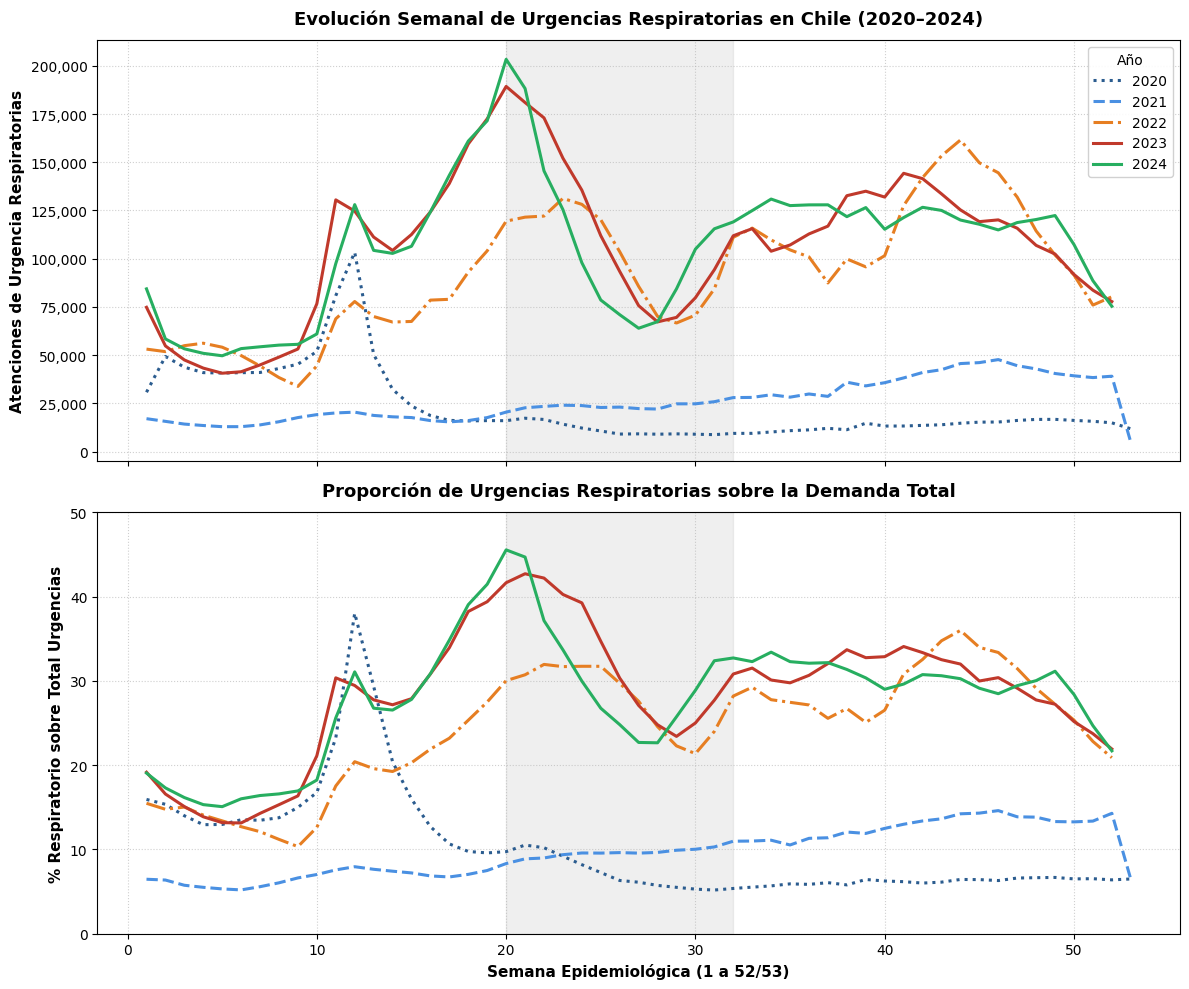

In [11]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

colores = {2020: '#2b5c8f', 2021: '#4a90e2', 2022: '#e67e22', 2023: '#c0392b', 2024: '#27ae60'}
estilos = {2020: ':', 2021: '--', 2022: '-.', 2023: '-', 2024: '-'}

for anio in sorted(semanal_piv['Año'].unique()):
    sub = semanal_piv[semanal_piv['Año'] == anio].sort_values('Semana')
    ax1.plot(sub['Semana'], sub['Urgencias_Resp'], label=f"{anio}", color=colores[anio], 
             linestyle=estilos[anio], linewidth=2.2)
    ax2.plot(sub['Semana'], sub['Pct_Resp'], label=f"{anio}", color=colores[anio], 
             linestyle=estilos[anio], linewidth=2.2)

ax1.set_ylabel("Atenciones de Urgencia Respiratorias", fontsize=11, fontweight='bold')
ax1.set_title("Evolución Semanal de Urgencias Respiratorias en Chile (2020–2024)", fontsize=13, fontweight='bold', pad=12)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(title="Año", frameon=True, facecolor='white', framealpha=0.9)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{int(x):,}"))

# Sombrear ventana crítica de Campaña de Invierno (semanas 20 a 32)
ax1.axvspan(20, 32, color='gray', alpha=0.12, label="Ventana crítica de invierno (S20-S32)")
ax2.axvspan(20, 32, color='gray', alpha=0.12)

ax2.set_xlabel("Semana Epidemiológica (1 a 52/53)", fontsize=11, fontweight='bold')
ax2.set_ylabel("% Respiratorio sobre Total Urgencias", fontsize=11, fontweight='bold')
ax2.set_title("Proporción de Urgencias Respiratorias sobre la Demanda Total", fontsize=13, fontweight='bold', pad=12)
ax2.set_ylim(0, 50)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


## 4. Interpretación, alcance y límites

- **Unidad de análisis:** Recuento diario agregado por establecimiento, fecha, semana epidemiológica y código de causa. No permite rastrear pacientes individuales ni distinguir consultas repetidas de un mismo usuario.
- **Denominador:** `IdCausa == 1` ("SECCIÓN 1. TOTAL ATENCIONES DE URGENCIA"). Mide la participación de la patología respiratoria dentro del flujo total de la red de urgencia; no representa riesgo poblacional ni tasa de ataque.
- **Granularidad temporal:** Serie continua semanal (semanas 1 a 52/53) en los 5 años analizados, lo que permite modelar trayectorias de alta frecuencia a diferencia de series semestrales.
- **Choque exógeno de la pandemia:** 2020 y 2021 presentan niveles excepcionalmente bajos de circulación de virus respiratorios tradicionales producto de cuarentenas, uso masivo de mascarillas y cierre de colegios. No deben emplearse como línea base estándar para predecir años regulares.
- **Rol de la Atención Primaria:** Los datos demuestran que más del 75% de las consultas respiratorias de urgencia se resuelven en SAPU, SAR y SUR. Las alertas operacionales deben enfocarse en la capacidad de contención de la APS para evitar la sobredemanda de los servicios de urgencia hospitalaria.
- **Causalidad:** El estudio es descriptivo y analítico; no establece relaciones de causalidad biológica ni efectos de tratamientos médicos.


## 5. Ajuste a la rúbrica W1: Continuidad más allá de C1

### Potencial futuro de Machine Learning (ML)
- **Tarea formulada:** Modelo de **pronóstico semanal multivariado de atenciones respiratorias a corto plazo (horizonte de 2 a 4 semanas)** a nivel de Servicio de Salud o tipo de centro.
- **Utilidad operativa:** Alerta temprana para gatillar con anticipación la reconversión de camas críticas pediátricas y contratación de refuerzos médicos antes de que ocurra la saturación hospitalaria.
- **Datos requeridos y brechas identificadas:** Se requiere integrar variables exógenas:
  1. *Datos de vigilancia virológica del ISP:* circulación porcentual de Virus Sincicial Respiratorio (VRS), Influenza A/B, Metaneumovirus y Adenovirus.
  2. *Datos meteorológicos abiertos:* temperatura mínima media semanal y episodios críticos de contaminación del aire.
- **Línea base y métricas:** Modelo simple de referencia autorregresivo (Lag-1 y promedio estacional) evaluado con MAE y RMSE en partición temporal fuera de muestra (train: 2020–2023, test: 2024).

### Potencial futuro de Dashboard
- **Usuarios objetivos:** Encargados de Gestión de Camas de la DIGERA, directores de Servicios de Salud y jefaturas de Urgencia hospitalaria.
- **Decisiones a apoyar:** Monitoreo diario/semanal de la curva de demanda invernal frente a la capacidad instalada y seguimiento del desvío respecto al promedio histórico quinquenal.
- **Indicadores y vistas clave:**
  1. Curva epidémica semanal comparativa (año actual vs. banda histórica).
  2. Indicador de presión respiratoria: `% Respiratorio = IdCausa 2 / IdCausa 1` con semáforo de alerta (>30% zona de tensión asistencial).
  3. Desglose piramidal por tramo de edad para detectar precozmente si el brote afecta a lactantes (<1 año) o población geriátrica (65+).
  4. Balance de carga asistencial entre nivel primario (SAPU/SAR) y hospitalario.

### Preguntas concretas para el instructor (Tomás Fontecilla)
1. *¿Es preferible modelar la serie de Urgencias Respiratorias consolidada a nivel nacional (homogénea 2020–2024) o conviene acotar el análisis a 2023–2024 para aprovechar la granularidad regional ya denormalizada sin introducir ruido por joins de establecimientos?*
2. *Para el desfase extremo observado en 2020 y 2021 producto de las cuarentenas y medidas no farmacológicas de COVID-19, ¿recomienda excluir 2020 del cálculo de líneas base estacionales o mantenerlo como caso testigo de choque exógeno?*
3. *Dado que más del 75% de las atenciones respiratorias ocurren en SAPU y SAR, ¿considera conveniente que la pregunta de negocio se enfoque en la capacidad de absorción de la Atención Primaria de Urgencia (APS) para evitar la saturación hospitalaria?*


## 6. Bitácora de proceso (Process record preliminar)

| Dimensión | Registro del equipo |
|---|---|
| **Decisiones y chequeos** | - Se definió `IdCausa == 2` como numerador y `IdCausa == 1` como denominador total de demanda.<br>- Se decidió leer directamente los archivos `.zip` mediante agregación al vuelo (*streaming chunk aggregation*) para procesar 42 millones de registros en solo 1,2 MB de RAM sin sobrecargar memoria.<br>- Se comprobó empíricamente que COVID-19 no está incluido en `IdCausa == 2` y se evaluó su impacto en un análisis de sensibilidad.<br>- Se auditaron las Five Cs comprobando consistencia aritmética perfecta (0 discrepancias entre Total y suma de edades). |
| **Retroalimentación del docente** | Pendiente de presentación en la sesión de taller. Se formularon 3 preguntas concretas en la Sección 5. |
| **Contribución individual** | - Integrante 1 (Benjamín): Formulación de la Candidata 1 (Urgencias Respiratorias), análisis de estacionalidad semanal, verificación de Five Cs, análisis de sensibilidad y reconciliación de causas.<br>- Integrante 2 (Sebastián): Formulación de la Candidata 2 (REM-P2 Nutrición Infantil), inspección de diccionarios Serie P y comparabilidad temporal. |
| **Uso de IA y verificación** | Asistente de IA utilizado para la extracción de bloques desde archivos ZIP, redacción de consultas de agregación y generación de gráficos. Todas las cifras de atenciones, porcentajes y sumas fueron verificadas empíricamente contra los datos oficiales del DEIS. |
| **Reflexión individual** | - *Contribución:* Procesamiento eficiente de más de 42 millones de registros de atenciones de urgencia y auditoría de calidad Five Cs.<br>- *Aprendizaje:* Comprender que los registros SADU miden recuentos de eventos asistenciales y que más del 75% de la carga de invierno se resuelve en APS (SAPU/SAR) y no en hospitales.<br>- *Incertidumbre pendiente:* Definir cómo tratar metodológicamente el choque de las cuarentenas de 2020 en un futuro modelo de series de tiempo. |
